In [1]:
!pip install open_clip_torch==2.23.0 transformers==4.35.2

  Obtaining dependency information for sympy>=1.13.3 from https://files.pythonhosted.org/packages/a2/09/77d55d46fd61b4a135c444fc97158ef34a095e5681d0a6c10b75bf356191/sympy-1.14.0-py3-none-any.whl.metadata
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
from qiskit_machine_learning.utils import algorithm_globals
from pathlib import Path
import random
import pandas as pd
import time
import numpy as np
import sys
from quantum.ansatz import construct_tensor_ring_ansatz_circuit
from quantum.feature_map import *
from quantum.QNN import construct_qnn

from loguru import logger

import torch
from PIL import Image
import open_clip
from sklearn.decomposition import PCA
from classic.ModelsMNIST import TripletAutoencoder, train_triplet_autoencoder, extract_embeddings

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm

from IPython.display import clear_output
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import manifold
import os
torch.manual_seed(123)

seed_value = 12345
algorithm_globals.random_seed = seed_value
np.random.seed(seed_value)
random.seed(seed_value)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_qubits = 8
n_features = 8

# for binary classification we undersample the training data
undersampling = True
n_samples = 300

maxiter = 1000

logger.info(f'Project path {sys.path}')
path_data = Path('./data/Brain_Stroke_CT_Dataset')
path_data_test = Path('./data/Brain_Stroke_CT_Dataset/External_Test')

logger.info(f'Train path: {path_data}')
logger.info(f'Test path: {path_data_test}')

folder_type = 'PNG'

train_folder = ['Normal', 'Ischemia', 'Bleeding']
bin_classes = { 'Normal': 0, 'Ischemia': 1, 'Bleeding': 1}
multi_classes = { 'Normal': 0, 'Ischemia': 1, 'Bleeding': 2}

2026-04-03 11:59:49.841 | INFO     | __main__:<module>:50 - Project path ['/Users/vitolosavio/PycharmProjects/quantum-tensor-networks-circuits', '/Library/Frameworks/Python.framework/Versions/3.10/lib/python310.zip', '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10', '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/lib-dynload', '', '/Users/vitolosavio/PycharmProjects/quantum-tensor-networks-circuits/.venv/lib/python3.10/site-packages']
2026-04-03 11:59:49.841 | INFO     | __main__:<module>:54 - Train path: data/Brain_Stroke_CT_Dataset
2026-04-03 11:59:49.842 | INFO     | __main__:<module>:55 - Test path: data/Brain_Stroke_CT_Dataset/External_Test


CSV construction to obtain an order with respect to images and classes belonging to a binary or multiclass task

In [8]:
bin_data = {'path': [], 'class': [], 'type': []}
multiclas_data = {'path': [], 'class': [], 'type': []}

try:
    bin_dataset = pd.read_csv(path_data / 'bin_data.csv')
    multiclass_dataset = pd.read_csv(path_data / 'multiclass_data.csv')
except FileNotFoundError:
    
    for paths in path_data.iterdir():
        sub_path = str(paths.resolve()).split('/')[-1]
        if sub_path in train_folder:
            data_path = paths / folder_type
            for img in data_path.iterdir():
                img_path = str(img.resolve()).replace(str(path_data.resolve()), "")
                bin_data['path'].append(img_path)
                bin_data['class'].append(bin_classes[str(sub_path)])
                bin_data['type'].append(sub_path)
                
                multiclas_data['path'].append(img_path)
                multiclas_data['class'].append(multi_classes[str(sub_path)])
                multiclas_data['type'].append(sub_path)
                
    bin_dataset = pd.DataFrame(bin_data)
    multiclass_dataset = pd.DataFrame(multiclas_data)
bin_dataset.head()

,path,class,type
0,/Bleeding/PNG/16585.png,1,Bleeding
1,/Bleeding/PNG/11598.png,1,Bleeding
2,/Bleeding/PNG/14386.png,1,Bleeding
3,/Bleeding/PNG/10876.png,1,Bleeding
4,/Bleeding/PNG/10889.png,1,Bleeding


In [9]:

multiclass_dataset.head()

,path,class,type
0,/Bleeding/PNG/16585.png,2,Bleeding
1,/Bleeding/PNG/11598.png,2,Bleeding
2,/Bleeding/PNG/14386.png,2,Bleeding
3,/Bleeding/PNG/10876.png,2,Bleeding
4,/Bleeding/PNG/10889.png,2,Bleeding


In [10]:
bin_dataset.to_csv(path_data / 'bin_data.csv', index=False)
multiclass_dataset.to_csv(path_data / 'multiclass_data.csv', index=False)

Data visualisation, cleaning and dimensionality reduction, choose one of the two dataset available

the dataset available are:
1. `data/bin_data.csv` for binary classification 
2. `data/multiclass_data.csv` for multiclass classification


In [11]:
bin_dataset = pd.read_csv(path_data / 'bin_data.csv')

In [12]:
labels = bin_dataset['class'].to_numpy()

imgs = []

for _, raw in tqdm(bin_dataset.iterrows(), total=len(bin_dataset)):
    img_path = str(path_data.resolve()) + raw['path']
    img = Image.open(img_path).convert("L").resize((512, 512))
    
    imgs.append(np.array(img))
    
len(imgs), len(labels)

  0%|          | 0/6650 [00:00<?, ?it/s]

(6650, 6650)

In [13]:
X = np.asarray(imgs)
X = X.astype(np.float32) / 255.0
y = labels.astype(np.int64)
X.shape, y.shape

((6650, 512, 512), (6650,))

In [14]:
X_flat = X.reshape(len(X), -1).astype(np.float32)

In [15]:
tsne = manifold.TSNE(n_components=2, random_state=42)
tr = tsne.fit_transform(X_flat)
cps_df = pd.DataFrame(columns=['CP1', 'CP2', 'target'],
                       data=np.column_stack((tr,
                                            labels)))
# cast targets column to int
cps_df.loc[:, 'target'] = cps_df.target.astype(int)
cps_df.head()

/Users/vitolosavio/PycharmProjects/quantum-tensor-networks-circuits/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/vitolosavio/PycharmProjects/quantum-tensor-networks-circuits/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/vitolosavio/PycharmProjects/quantum-tensor-networks-circuits/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/vitolosavio/PycharmProjects/quantum-tensor-networks-circuits/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/vitolosavio/PycharmProjects/quantum-tensor-networks-circuits/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: over

,CP1,CP2,target
0,32.503414,-69.771255,1.0
1,-6.589616,-32.349487,1.0
2,17.979458,16.609785,1.0
3,-23.630085,8.657620,1.0
4,12.669835,-31.645514,1.0


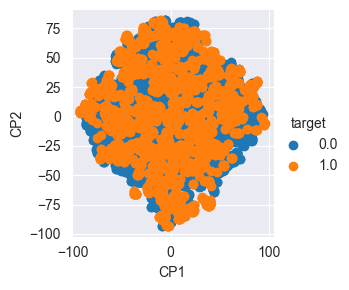

In [16]:
grid = sns.FacetGrid(cps_df, hue="target")
grid.map(plt.scatter, 'CP1', 'CP2').add_legend()

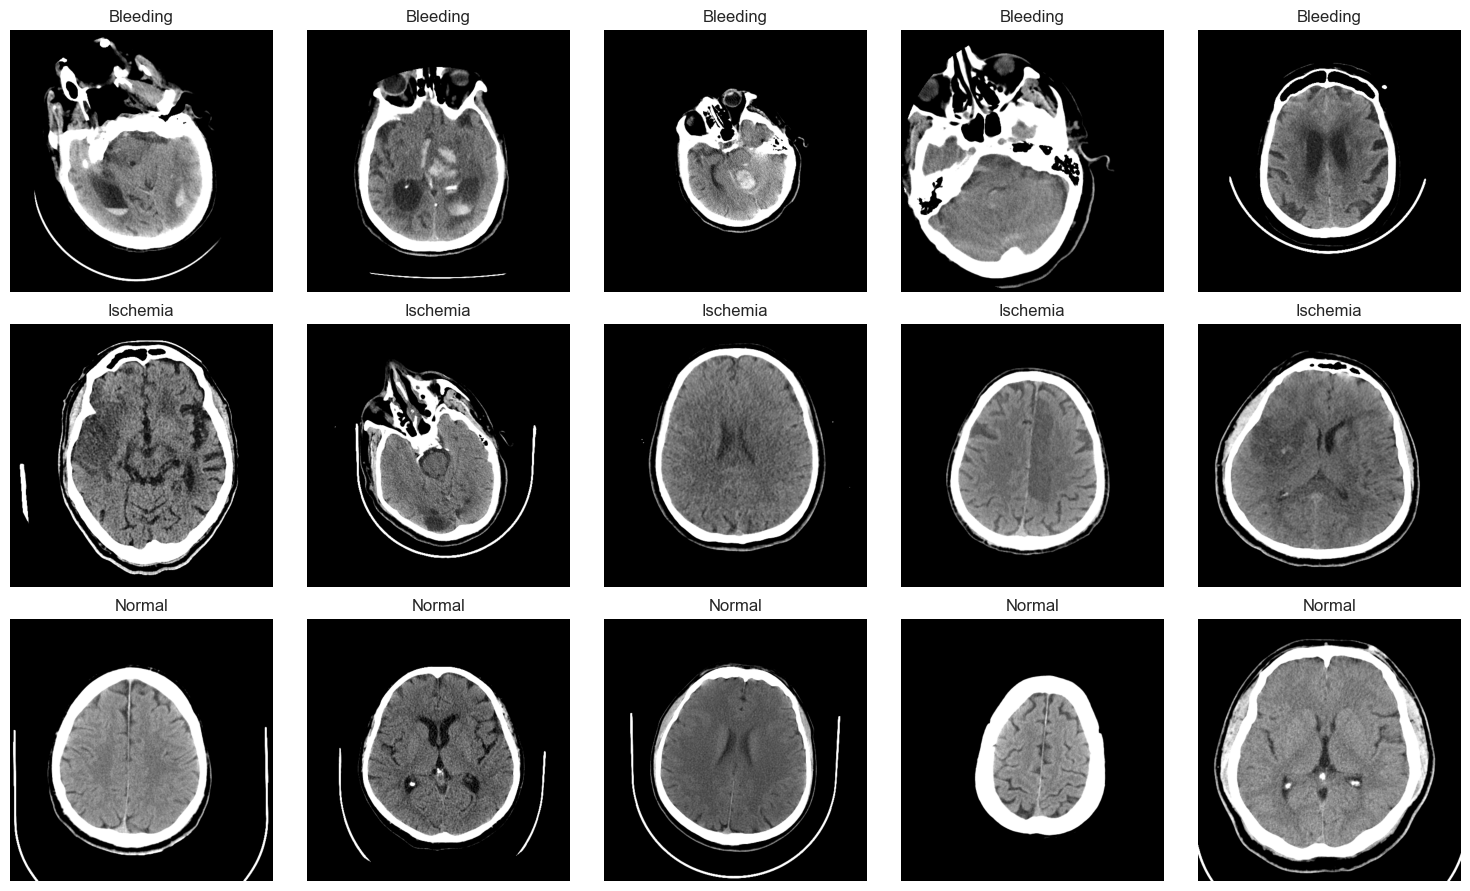

In [17]:
types = bin_dataset["type"].unique()
n = 5

fig, axes = plt.subplots(len(types), n, figsize=(n*3, len(types)*3))

for i, t in enumerate(types):
    subset = bin_dataset[bin_dataset["type"] == t]
    sample_paths = random.sample(subset["path"].tolist(), min(n, len(subset)))

    for j, rel_path in enumerate(sample_paths):
        img_path = str(path_data.resolve()) + rel_path
        try:
            img = Image.open(img_path).convert("RGB")
            axes[i, j].imshow(img)
        except Exception:
            axes[i, j].text(0.5, 0.5, "Error", ha="center", va="center")
        axes[i, j].set_title(t)
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

In [18]:
model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
tokenizer = open_clip.get_tokenizer(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)

/Users/vitolosavio/PycharmProjects/quantum-tensor-networks-circuits/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/vitolosavio/PycharmProjects/quantum-tensor-networks-circuits/.venv/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Training preprocessing,

In [20]:
model.to(device)
model.eval()

fe_data_train = None
col_name = None
with torch.no_grad():
    for n_raw, raw in tqdm(bin_dataset.iterrows(), total=len(bin_dataset)):
        img = raw['path']
        label = raw['class']
        image_features, _, logit_scale = model(
            torch.stack(
                [preprocess_train(Image.open(str(path_data) + img))]
            )
        )

        logits = (logit_scale * image_features).detach().softmax(dim=-1)

        logits = logits.cpu().numpy()
        
        if col_name is None:
            col_name = [ f'col_{i}' for i in range(logits.shape[1])]
        
        if fe_data_train is None:
            fe_data_train = pd.DataFrame(logits, columns=col_name)
            fe_data_train['class'] = label
        else:
            raw_concat = pd.DataFrame(logits, columns=col_name)
            raw_concat['class'] = label
            
            fe_data_train = pd.concat([fe_data_train, raw_concat])

fe_data_train.head()   

  0%|          | 0/6650 [00:00<?, ?it/s]

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_503,col_504,col_505,col_506,col_507,col_508,col_509,col_510,col_511,class
0,2.263873e-11,1.943867e-12,1.165668e-20,5.060680e-12,8.311332e-11,2.249962e-13,3.351336e-12,8.396521e-13,5.506794e-13,5.132289e-13,...,5.447444e-10,4.752935e-12,3.972435e-10,8.319401e-12,1.062802e-10,6.759005e-13,3.423016e-10,3.033485e-11,2.177811e-10,1
0,1.338367e-12,5.897246e-13,6.799112e-22,9.705174e-15,1.015093e-12,1.763868e-14,5.644771e-12,1.730083e-12,3.052502e-14,3.247748e-14,...,4.784131e-10,3.779289e-12,2.460565e-10,9.994180e-13,1.137827e-10,2.484795e-12,6.187793e-11,4.536125e-12,4.724722e-11,1
0,1.638471e-11,2.788212e-12,1.395691e-19,5.174631e-13,1.572994e-11,9.009096e-12,1.327832e-10,6.378155e-12,7.116391e-12,1.544344e-12,...,9.854526e-08,1.254153e-10,2.513823e-08,6.280196e-11,2.109353e-10,3.202969e-12,3.572194e-09,1.100442e-11,2.173537e-09,1
0,3.425815e-10,9.689937e-11,7.578406e-19,3.003932e-12,5.244449e-10,3.715190e-11,3.806074e-10,7.694151e-12,3.337104e-11,1.604593e-11,...,3.742911e-09,3.959146e-11,1.912123e-08,1.018284e-09,1.122032e-11,7.529996e-11,3.523054e-09,5.117587e-11,6.494436e-10,1
0,1.194054e-12,1.957733e-11,4.907810e-19,7.107850e-13,5.173276e-13,4.347016e-12,1.263851e-11,6.572411e-12,1.739255e-12,1.596130e-13,...,4.002412e-09,5.391610e-13,7.457550e-09,4.118179e-11,9.782414e-11,1.140764e-12,1.258531e-10,2.296863e-12,3.556261e-10,1


In [21]:
fe_data_train.shape, bin_dataset.shape

((6650, 513), (6650, 3))

In [22]:
fe_data_train.to_csv(path_data / 'extracted_feature_data_train.csv', index=False)

Test preprocessing

In [76]:
df_test = pd.read_csv(path_data_test / 'labels.csv')
df_test['Stroke'].value_counts()

Stroke
0    130
1     70
Name: count, dtype: int64

In [23]:
model.to(device)
model.eval()


fe_data_test = None
col_name = None
with torch.no_grad():
    for n_raw, raw in tqdm(df_test.iterrows(), total=len(df_test)):
        img = raw['image_id']
        
        img = path_data_test / folder_type /f'{img}.png'
        label = raw['Stroke']
        image_features, _, logit_scale = model(
            torch.stack(
                [preprocess_train(Image.open(img))]
            )
        )

        logits = (logit_scale * image_features).detach().softmax(dim=-1)

        logits = logits.cpu().numpy()
        
        if col_name is None:
            col_name = [ f'col_{i}' for i in range(logits.shape[1])]
        
        if fe_data_test is None:
            fe_data_test = pd.DataFrame(logits, columns=col_name)
            fe_data_test['class'] = label
        else:
            raw_concat = pd.DataFrame(logits, columns=col_name)
            raw_concat['class'] = label
            
            fe_data_test = pd.concat([fe_data_test, raw_concat])

fe_data_test.head()   

  0%|          | 0/200 [00:00<?, ?it/s]

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_503,col_504,col_505,col_506,col_507,col_508,col_509,col_510,col_511,class
0,1.709387e-11,7.531175e-14,8.773385e-22,1.565649e-13,1.850339e-13,7.458581e-15,1.597494e-13,6.426762e-13,3.991459e-12,2.360570e-13,...,1.345659e-12,5.280806e-13,1.554362e-11,6.094449e-12,1.869727e-13,3.614844e-13,1.192216e-11,1.435652e-13,9.992604e-12,0
0,7.905735e-13,2.172441e-14,5.216814e-22,9.201098e-15,1.654710e-13,8.663301e-16,1.926114e-12,9.198826e-13,2.937487e-13,1.707557e-14,...,8.017002e-11,7.851997e-13,7.991689e-11,1.345309e-12,2.995568e-12,2.602434e-13,1.558346e-11,4.421397e-13,1.906161e-10,0
0,6.578375e-12,5.737086e-14,1.233261e-23,2.794348e-14,3.474388e-13,3.960759e-14,1.488206e-13,2.106873e-13,6.521665e-13,2.468833e-13,...,1.184331e-12,1.487309e-13,1.474510e-11,6.775256e-12,1.132307e-14,4.018916e-13,1.001450e-11,1.849892e-13,8.579735e-12,0
0,1.060281e-12,1.660709e-13,4.551337e-21,8.710758e-13,1.980877e-11,4.604702e-15,7.723091e-13,3.855464e-13,4.131130e-13,1.745724e-13,...,5.646313e-10,2.006897e-11,1.394456e-09,1.021243e-11,3.614536e-10,6.568970e-13,3.599282e-11,3.938887e-12,9.574713e-12,0
0,5.523003e-12,2.170380e-13,2.110205e-22,1.187787e-14,1.466902e-12,9.554573e-15,3.216443e-12,5.846967e-12,1.209908e-13,2.681258e-13,...,9.002112e-11,2.140138e-12,1.118653e-10,1.903391e-12,2.008547e-11,3.372245e-12,2.058285e-11,5.144423e-12,2.453515e-10,0


In [24]:
fe_data_test.to_csv(path_data / 'extracted_feature_data_test.csv', index=False)

In [82]:
fe_data_train = pd.read_csv(path_data / 'extracted_feature_data_train.csv')
fe_data_test = pd.read_csv(path_data / 'extracted_feature_data_test.csv')

n_classes = len(fe_data_train['class'].unique())
logger.info(f'The train dataset contains {n_classes} classes.')
logger.info(f"The test dataset contains {len(fe_data_test['class'].unique())} classes.")

if n_classes == 3:
    # this is done because the original test dataset supports only binary classification
    fe_data_train = pd.concat([fe_data_train, fe_data_test])
    y_true= fe_data_train.pop('class')
    
    X_train, X_test, y_train, y_test = train_test_split(
        fe_data_train, 
        y_true,
        test_size=0.3,
        random_state=42,
        stratify=y_true,
        shuffle=True
    )
else: 
    X_train = fe_data_train
    y_train = X_train.pop('class')
    
    X_test = fe_data_test
    y_test = X_test.pop('class')
    

2026-04-03 11:07:36.869 | INFO     | __main__:<module>:5 - The train dataset contains 2 classes.
2026-04-03 11:07:36.871 | INFO     | __main__:<module>:6 - The test dataset contains 2 classes.


In [83]:
scaler = MinMaxScaler()
scaler.fit(X_train, y_train)

X_train = scaler.transform(X_train)
X_train

array([[5.62831258e-05, 6.95759006e-06, 7.97053259e-07, ...,
        1.67300911e-04, 3.02280988e-04, 4.84706982e-05],
       [3.30542277e-06, 2.10951154e-06, 4.64892782e-08, ...,
        3.02357983e-05, 4.51771746e-05, 1.05047939e-05],
       [4.07283025e-05, 9.98049801e-06, 9.54338667e-06, ...,
        1.74600311e-03, 1.09638592e-04, 4.83879955e-04],
       ...,
       [3.72259823e-04, 2.88406932e-04, 1.60103094e-05, ...,
        4.47043674e-03, 1.45788690e-03, 1.18301231e-03],
       [9.58935312e-06, 1.24648299e-07, 3.14238722e-09, ...,
        1.47576152e-06, 1.92179655e-06, 4.27364875e-06],
       [9.53014098e-06, 5.66615731e-08, 6.52988280e-09, ...,
        3.23342959e-06, 6.99457574e-07, 1.12740589e-06]])

In [84]:
X_test = scaler.transform(X_test)
X_test

array([[4.24920966e-05, 2.67819322e-07, 5.99888641e-08, ...,
        5.81848765e-06, 1.40199189e-06, 2.21081038e-06],
       [1.94296575e-06, 7.59668300e-08, 3.56699174e-08, ...,
        7.60805381e-06, 4.37751258e-06, 4.24229605e-05],
       [1.63382317e-05, 2.03587650e-07, 8.41920875e-10, ...,
        4.88606275e-06, 1.81481384e-06, 1.89626379e-06],
       ...,
       [2.16019755e-06, 3.93646608e-08, 4.82661532e-10, ...,
        6.55814163e-07, 4.53581467e-07, 6.82526636e-07],
       [1.23774958e-05, 7.97531530e-08, 3.94763454e-10, ...,
        3.65973038e-06, 2.58136559e-06, 5.34045347e-06],
       [6.96783065e-05, 1.10575721e-05, 1.56601169e-06, ...,
        2.29307079e-04, 2.92299837e-05, 1.92102200e-06]])

In [85]:
np.unique(y_train), np.unique(y_test), device, X_train.max(), X_test.max()

(array([0, 1]),
 array([0, 1]),
 device(type='cpu'),
 np.float64(1.0000000000000002),
 np.float64(4.064764053804084))

Triplet Autoencoder

In [86]:
autoencoder = TripletAutoencoder(input_dim=X_train.shape[1], bottleneck_dim=n_features)

In [87]:
autoencoder = train_triplet_autoencoder(
    autoencoder, 
    X_train, 
    y_train.to_numpy(),
    n_epochs=250,
    batch_size=300, 
    lr=1e-3,
    margin=1.,
    alpha=1.,
)

Epoch 1/250, Loss: 22.0756
Epoch 2/250, Loss: 20.7947
Epoch 3/250, Loss: 19.4127
Epoch 4/250, Loss: 18.0907
Epoch 5/250, Loss: 17.4487
Epoch 6/250, Loss: 16.7941
Epoch 7/250, Loss: 16.3609
Epoch 8/250, Loss: 15.9524
Epoch 9/250, Loss: 15.6018
Epoch 10/250, Loss: 15.2970
Epoch 11/250, Loss: 15.1968
Epoch 12/250, Loss: 14.9986
Epoch 13/250, Loss: 14.8464
Epoch 14/250, Loss: 14.6291
Epoch 15/250, Loss: 14.5404
Epoch 16/250, Loss: 14.5236
Epoch 17/250, Loss: 14.1175
Epoch 18/250, Loss: 14.0569
Epoch 19/250, Loss: 14.2304
Epoch 20/250, Loss: 13.9185
Epoch 21/250, Loss: 13.6919
Epoch 22/250, Loss: 13.4832
Epoch 23/250, Loss: 13.8067
Epoch 24/250, Loss: 13.5520
Epoch 25/250, Loss: 13.2454
Epoch 26/250, Loss: 13.4040
Epoch 27/250, Loss: 13.1191
Epoch 28/250, Loss: 13.2498
Epoch 29/250, Loss: 13.1851
Epoch 30/250, Loss: 13.0716
Epoch 31/250, Loss: 12.7255
Epoch 32/250, Loss: 12.7969
Epoch 33/250, Loss: 12.5245
Epoch 34/250, Loss: 12.5187
Epoch 35/250, Loss: 12.7646
Epoch 36/250, Loss: 12.4927
E

In [88]:
X_train_emb = extract_embeddings(autoencoder, X_train)
X_test_emb = extract_embeddings(autoencoder, X_test)

In [89]:
X_train_emb.shape, X_test_emb.shape

((6650, 8), (200, 8))

In [90]:
X_train_emb = (X_train_emb - X_train_emb.min()) * (np.pi / (X_train_emb.max() - X_train_emb.min()))
X_test_emb = (X_test_emb - X_test_emb.max()) * (np.pi / (X_test_emb.max() - X_test_emb.min()))

In [91]:
col_name = [ f'col_{i}' for i in range(X_train_emb.shape[1])]

processed_df = pd.DataFrame(X_train_emb, columns=col_name)
processed_df['classes'] = y_train.to_numpy()

processed_df.to_csv(path_data / f'T-AE_processed_data_train_{n_features}_features.csv', index=False)

processed_df = pd.DataFrame(X_test_emb, columns=col_name)
processed_df['classes'] = y_test.to_numpy()

processed_df.to_csv(path_data / f'T-AE_processed_data_test_{n_features}_features.csv', index=False)

In [92]:
classes = y_train.unique()
logger.info([f'Number of Example:{len(y_train[y_train == i])}, for Class {i}' for i in classes])

2026-04-03 11:40:55.355 | INFO     | __main__:<module>:2 - ['Number of Example:2223, for Class 1', 'Number of Example:4427, for Class 0']


PCA Reduction

In [60]:
pca = PCA(n_components=n_features)
X_train_emb = pca.fit_transform(X_train)
X_test_emb = pca.transform(X_test)

/Users/vitolosavio/PycharmProjects/quantum-tensor-networks-circuits/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/vitolosavio/PycharmProjects/quantum-tensor-networks-circuits/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/vitolosavio/PycharmProjects/quantum-tensor-networks-circuits/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/vitolosavio/PycharmProjects/quantum-tensor-networks-circuits/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/vitolosavio/PycharmProjects/quantum-tensor-networks-circuits/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: over

In [62]:
logger.info(f'{X_train_emb.shape}, {X_test_emb.shape}')

2026-04-03 10:35:32.197 | INFO     | __main__:<module>:1 - (600, 8), (6250, 8)


In [63]:
X_train_emb = (X_train_emb - X_train_emb.min()) * (np.pi / (X_train_emb.max() - X_train_emb.min()))
X_test_emb = (X_test_emb - X_test_emb.min()) * (np.pi / (X_test_emb.max() - X_test_emb.min()))
col_name = [ f'col_{i}' for i in range(X_train_emb.shape[1])]

processed_df = pd.DataFrame(X_train_emb, columns=col_name)
processed_df['classes'] = y_train.to_numpy()

processed_df.to_csv(path_data / f'PCA_processed_data_train_{n_features}_features.csv', index=False)

processed_df = pd.DataFrame(X_test_emb, columns=col_name)
processed_df['classes'] = y_test.to_numpy()

processed_df.to_csv(path_data / f'PCA_processed_data_test_{n_features}_features.csv', index=False)

Train of VQAs models, for this step you can choose between two processed dataset:
1. `f'T-AE_processed_data_train_{n_features}_features.csv'` and `f'T-AE_processed_data_test_{n_features}_features.csv'` for the dataset reduced using the PCA
2. `f'T-AE_processed_data_train_{n_features}_features.csv'` and `f'T-AE_processed_data_test_{n_features}_features.csv'` for the dataset reduced using the Triplet-Autoencoder architecture 

In [2]:
def sample_per_class(df, label_col, n_examples=50, random_state=42):
    return (
        df.groupby(label_col, group_keys=False)
          .apply(lambda x: x.sample(
              n=n_examples,
              random_state=random_state
          ))
    )

In [4]:
X_train = pd.read_csv(path_data / f'T-AE_processed_data_train_{n_features}_features.csv')
X_test = pd.read_csv(path_data / f'T-AE_processed_data_test_{n_features}_features.csv')

if undersampling:
    logger.info(f'Using undersampling')
    logger.info(f'Initial classes distribution train: {X_train["classes"].value_counts().to_dict()}')
    X_train_res = sample_per_class(X_train, label_col="classes", n_examples=n_samples)

    X_train_rest = X_train[~X_train.index.isin(X_train_res.index.values.tolist())]
    
    X_test = pd.concat([X_test, X_train_rest], axis=0)
    X_train = X_train_res
    
    logger.info(f'Classes distribution train after sampling: {X_train["classes"].value_counts().to_dict()}')
    
    X_train.reset_index(drop=True, inplace=True)
    X_test.reset_index(drop=True, inplace=True)



y_train = X_train.pop('classes')
y_test = X_test.pop('classes')

2026-04-03 12:00:01.403 | INFO     | __main__:<module>:5 - Using undersampling
2026-04-03 12:00:01.406 | INFO     | __main__:<module>:6 - Initial classes distribution train: {0: 4427, 1: 2223}
/var/folders/gs/btws2d7x5pj_z8qr696bjys80000gn/T/ipykernel_47720/3060710556.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
2026-04-03 12:00:01.413 | INFO     | __main__:<module>:14 - Classes distribution train after sampling: {0: 300, 1: 300}


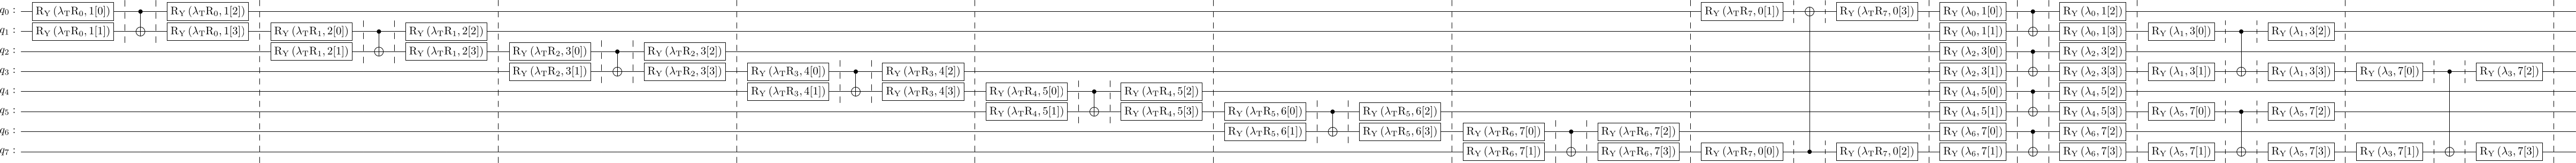

In [5]:
feature_map = encoding_features_h_ry(n_qubits)

ansatz, _  = construct_tensor_ring_ansatz_circuit(n_qubits)

ansatz.draw('latex', fold=1)

In [6]:
objective_func_vals = []
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective Function Value vs. Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective Function Value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()
    
qnn = construct_qnn(
    feature_map=feature_map,
    ansatz=ansatz,
    callback_graph=callback_graph,
    maxiter=maxiter,
    interpret=None,
    output_shape=2,
    type_ova='vqc'
)

2026-04-03 12:00:04.052 | INFO     | quantum.QNN:construct_qnn:27 - Run on: CPU


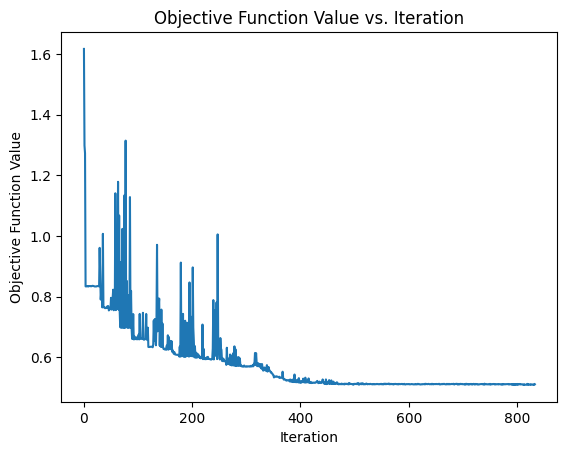

2026-04-03 12:23:33.689 | INFO     | __main__:<module>:7 - Time fit: 00:23:30
2026-04-03 12:23:35.334 | INFO     | __main__:<module>:9 - Accuracy in Train:
2026-04-03 12:23:52.971 | INFO     | __main__:<module>:10 - Accuracy in Test:


In [7]:
start_time = time.time()
qnn.fit(X_train, y_train.to_numpy())
end_time = time.time() - start_time

m, s = divmod(end_time, 60)
h, m = divmod(m, 60)
logger.info(f'Time fit: {round(h):>02}:{round(m):>02}:{round(s):>02}')

logger.info('Accuracy in Train:', qnn.score(X_train, y_train))
logger.info('Accuracy in Test:', qnn.score(X_test, y_test))


In [8]:
y_pred = qnn.predict(X_train)
logger.info('Classification report train')
logger.info(classification_report(y_train, y_pred, digits=2))

logger.info('Classification report test')
y_pred = qnn.predict(X_test)
logger.info(classification_report(y_test, y_pred, digits=2))


2026-04-03 12:23:54.524 | INFO     | __main__:<module>:2 - Classification report train
2026-04-03 12:23:54.528 | INFO     | __main__:<module>:3 -               precision    recall  f1-score   support

           0       0.82      0.97      0.89       300
           1       0.97      0.78      0.87       300

    accuracy                           0.88       600
   macro avg       0.89      0.88      0.88       600
weighted avg       0.89      0.88      0.88       600

2026-04-03 12:23:54.528 | INFO     | __main__:<module>:5 - Classification report test
2026-04-03 12:24:11.748 | INFO     | __main__:<module>:7 -               precision    recall  f1-score   support

           0       0.91      0.96      0.94      4257
           1       0.91      0.80      0.85      1993

    accuracy                           0.91      6250
   macro avg       0.91      0.88      0.90      6250
weighted avg       0.91      0.91      0.91      6250

